# TAHAP 4 - EVALUASI: Perbandingan 3 Model Deteksi Fraud

Pada tahap ini kita akan membandingkan **3 model** pada data test yang SAMA:

1. **BASELINE - Isolation Forest Sendirian**: model unsupervised sederhana
   - Menggunakan skor anomali dari Lapis 1
   - Tidak melihat label fraud saat training

2. **Random Forest + Isolation Forest Score**: model supervised dengan fitur dasar + skor IF
   - Belajar dari label fraud (supervised)
   - Menggunakan fitur perilaku + skor anomali IF

3. **XGBoost + Isolation Forest Score**: model advanced dengan fitur dasar + skor IF
   - Belajar dari label fraud (supervised)
   - Menggunakan fitur perilaku + skor anomali IF

**Metrik Evaluasi:**
- Precision: dari yang ditandai fraud, berapa % yang benar fraud?
- Recall: dari semua fraud yang ada, berapa % yang tertangkap?
- F1: harmonic mean dari precision & recall
- PR-AUC: ringkasan keseimbangan precision-recall (cocok untuk data tak seimbang)

##  Import & Konfigurasi

In [9]:
import os
import sys
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#   Path Model & Test Split  
RF_MODEL_PATH = "models/supervised_rf.pkl"
XGB_MODEL_PATH = "models/supervised_xgb.pkl"
IF_MODEL_PATH = "models/isolation_forest.pkl"
SPLIT_PATH = "models/test_split.pkl"

print("Import & konfigurasi selesai")

Import & konfigurasi selesai


##  Load Model & Test Split

In [10]:
print("[1/7] Memuat model dan test split...\n")

# Cek ketersediaan file
files_needed = {
    "RF Model": RF_MODEL_PATH,
    "IF Model": IF_MODEL_PATH,
    "Test Split": SPLIT_PATH,
}

for name, path in files_needed.items():
    status = "✓" if os.path.exists(path) else "✗"
    print(f"  {status} {name:20s} {path}")

# Cek ketersediaan XGBoost (opsional)
xgb_exists = os.path.exists(XGB_MODEL_PATH)
status_xgb = "✓" if xgb_exists else "✗"
print(f"  {status_xgb} {'XGB Model':20s} {XGB_MODEL_PATH}")

# Load model
try:
    rf_clf = joblib.load(RF_MODEL_PATH)
    if_model = joblib.load(IF_MODEL_PATH)
    split_data = joblib.load(SPLIT_PATH)
    X_te = split_data["X_test"]
    y_te = split_data["y_test"].astype(int)
    
    print(f"\n   Load berhasil")
    print(f"    Test set: {len(y_te):,} baris | Fraud: {int(y_te.sum())} ({y_te.mean():.1%})")
    print(f"    Fitur: {X_te.shape[1]} kolom")
    
except Exception as e:
    print(f"\n  [!] Error saat load: {e}")
    print(f"      Jalankan 02_train_supervised.ipynb dulu")
    raise

# Load XGBoost (opsional)
if xgb_exists:
    try:
        xgb_clf = joblib.load(XGB_MODEL_PATH)
        print(f"     XGBoost model loaded")
    except Exception as e:
        xgb_clf = None
        print(f"    [!] XGBoost load gagal: {e}")
else:
    xgb_clf = None
    print(f"    [-] XGBoost model tidak ada (akan lewat)")

[1/7] Memuat model dan test split...

  ✓ RF Model             models/supervised_rf.pkl
  ✓ IF Model             models/isolation_forest.pkl
  ✓ Test Split           models/test_split.pkl
  ✓ XGB Model            models/supervised_xgb.pkl

   Load berhasil
    Test set: 635 baris | Fraud: 35 (5.5%)
    Fitur: 10 kolom
     XGBoost model loaded


##  Prediksi Ketiga Model

In [11]:
print("[2/7] Melakukan prediksi ketiga model...\n")

#  MODEL 1: Isolation Forest Baseline 
# Skor IF sudah ada di kolom fitur 'if_anomaly_score' (makin tinggi = makin aneh)
if_score = X_te["if_anomaly_score"].values
frac_fraud = float(y_te.mean())
thresh_if = np.quantile(if_score, 1 - frac_fraud)
y_pred_if = (if_score >= thresh_if).astype(int)
y_proba_if = if_score / if_score.max()  # normalisasi ke 0..1 untuk PR curve

print(f"  MODEL 1: Isolation Forest BASELINE")
print(f"    Ambang (persentil {1 - frac_fraud:.1%}): {thresh_if:.4f}")
print(f"    Prediksi fraud: {int(y_pred_if.sum())} transaksi")

#  MODEL 2: Random Forest 
y_proba_rf = rf_clf.predict_proba(X_te)[:, 1]   # peluang fraud 0..1
y_pred_rf = rf_clf.predict(X_te)

print(f"\n  MODEL 2: Random Forest + IF Score")
print(f"    Prediksi fraud: {int(y_pred_rf.sum())} transaksi")

#  MODEL 3: XGBoost 
if xgb_clf is not None:
    y_proba_xgb = xgb_clf.predict_proba(X_te)[:, 1]
    y_pred_xgb = xgb_clf.predict(X_te)
    
    print(f"\n  MODEL 3: XGBoost + IF Score")
    print(f"    Prediksi fraud: {int(y_pred_xgb.sum())} transaksi")
else:
    y_proba_xgb = None
    y_pred_xgb = None
    print(f"\n  MODEL 3: XGBoost - LEWAT (model tidak tersedia)")

print(f"\n  Kenyataan: {int(y_te.sum())} transaksi fraud di test set")

[2/7] Melakukan prediksi ketiga model...

  MODEL 1: Isolation Forest BASELINE
    Ambang (persentil 94.5%): -0.0059
    Prediksi fraud: 35 transaksi

  MODEL 2: Random Forest + IF Score
    Prediksi fraud: 35 transaksi

  MODEL 3: XGBoost + IF Score
    Prediksi fraud: 35 transaksi

  Kenyataan: 35 transaksi fraud di test set


##  Confusion Matrix Ketiga Model

In [12]:
print("[3/7] Menampilkan Confusion Matrix...\n")

def print_confusion_matrix(y_true, y_pred, title):
    """Cetak confusion matrix dengan format rapi."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    print(f"  {title}")
    print("                      Prediksi: Normal   Prediksi: Fraud")
    print(f"  Asli: Normal              {tn:5d}              {fp:5d}   <- False Positive")
    print(f"  Asli: Fraud               {fn:5d}              {tp:5d}   <- True Positive")
    
    return tn, fp, fn, tp

print(" CONFUSION MATRIX - KETIGA MODEL")

tn_if, fp_if, fn_if, tp_if = print_confusion_matrix(
    y_te, y_pred_if, "MODEL 1: Isolation Forest BASELINE")
print()

tn_rf, fp_rf, fn_rf, tp_rf = print_confusion_matrix(
    y_te, y_pred_rf, "MODEL 2: Random Forest + IF Score")
print()

if y_pred_xgb is not None:
    tn_xgb, fp_xgb, fn_xgb, tp_xgb = print_confusion_matrix(
        y_te, y_pred_xgb, "MODEL 3: XGBoost + IF Score")
else:
    print("  MODEL 3: XGBoost + IF Score - LEWAT")

[3/7] Menampilkan Confusion Matrix...

 CONFUSION MATRIX - KETIGA MODEL
  MODEL 1: Isolation Forest BASELINE
                      Prediksi: Normal   Prediksi: Fraud
  Asli: Normal                592                  8   <- False Positive
  Asli: Fraud                   8                 27   <- True Positive

  MODEL 2: Random Forest + IF Score
                      Prediksi: Normal   Prediksi: Fraud
  Asli: Normal                598                  2   <- False Positive
  Asli: Fraud                   2                 33   <- True Positive

  MODEL 3: XGBoost + IF Score
                      Prediksi: Normal   Prediksi: Fraud
  Asli: Normal                599                  1   <- False Positive
  Asli: Fraud                   1                 34   <- True Positive


##  Tabel Perbandingan Metrik

In [13]:
print("[4/7] Tabel Perbandingan Metrik...\n")

def calculate_metrics(y_true, y_pred, y_proba):
    """Hitung semua metrik untuk satu model."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_proba)
    return precision, recall, f1, pr_auc

# Hitung metrik untuk ketiga model
p_if, r_if, f1_if, pr_auc_if = calculate_metrics(y_te, y_pred_if, y_proba_if)
p_rf, r_rf, f1_rf, pr_auc_rf = calculate_metrics(y_te, y_pred_rf, y_proba_rf)

if y_pred_xgb is not None:
    p_xgb, r_xgb, f1_xgb, pr_auc_xgb = calculate_metrics(y_te, y_pred_xgb, y_proba_xgb)

# Buat tabel perbandingan
comparison_data = {
    "Metrik": ["Precision", "Recall", "F1-Score", "PR-AUC"],
    "IF Baseline": [f"{p_if:.3f}", f"{r_if:.3f}", f"{f1_if:.3f}", f"{pr_auc_if:.3f}"],
    "Random Forest": [f"{p_rf:.3f}", f"{r_rf:.3f}", f"{f1_rf:.3f}", f"{pr_auc_rf:.3f}"],
}

if y_pred_xgb is not None:
    comparison_data["XGBoost"] = [f"{p_xgb:.3f}", f"{r_xgb:.3f}", f"{f1_xgb:.3f}", f"{pr_auc_xgb:.3f}"]

df_comparison = pd.DataFrame(comparison_data)

print(" PERBANDINGAN METRIK - KETIGA MODEL")
print(df_comparison.to_string(index=False))

# Analisis perbandingan
print(" ANALISIS PERBANDINGAN")

print(f"\n  RF vs IF Baseline:")
print(f"    F1-Score  : {f1_rf:.3f} vs {f1_if:.3f}  ({f1_rf - f1_if:+.3f})")
print(f"    PR-AUC    : {pr_auc_rf:.3f} vs {pr_auc_if:.3f}  ({pr_auc_rf - pr_auc_if:+.3f})")

if y_pred_xgb is not None:
    print(f"\n  XGBoost vs IF Baseline:")
    print(f"    F1-Score  : {f1_xgb:.3f} vs {f1_if:.3f}  ({f1_xgb - f1_if:+.3f})")
    print(f"    PR-AUC    : {pr_auc_xgb:.3f} vs {pr_auc_if:.3f}  ({pr_auc_xgb - pr_auc_if:+.3f})")
    
    print(f"\n  XGBoost vs RF:")
    print(f"    F1-Score  : {f1_xgb:.3f} vs {f1_rf:.3f}  ({f1_xgb - f1_rf:+.3f})")
    print(f"    PR-AUC    : {pr_auc_xgb:.3f} vs {pr_auc_rf:.3f}  ({pr_auc_xgb - pr_auc_rf:+.3f})")

[4/7] Tabel Perbandingan Metrik...

 PERBANDINGAN METRIK - KETIGA MODEL
   Metrik IF Baseline Random Forest XGBoost
Precision       0.771         0.943   0.971
   Recall       0.771         0.943   0.971
 F1-Score       0.771         0.943   0.971
   PR-AUC       0.788         0.984   0.992
 ANALISIS PERBANDINGAN

  RF vs IF Baseline:
    F1-Score  : 0.943 vs 0.771  (+0.171)
    PR-AUC    : 0.984 vs 0.788  (+0.196)

  XGBoost vs IF Baseline:
    F1-Score  : 0.971 vs 0.771  (+0.200)
    PR-AUC    : 0.992 vs 0.788  (+0.204)

  XGBoost vs RF:
    F1-Score  : 0.971 vs 0.943  (+0.029)
    PR-AUC    : 0.992 vs 0.984  (+0.008)


##  Visualisasi PR Curve Ketiga Model

[5/7] Visualisasi Precision-Recall Curve...



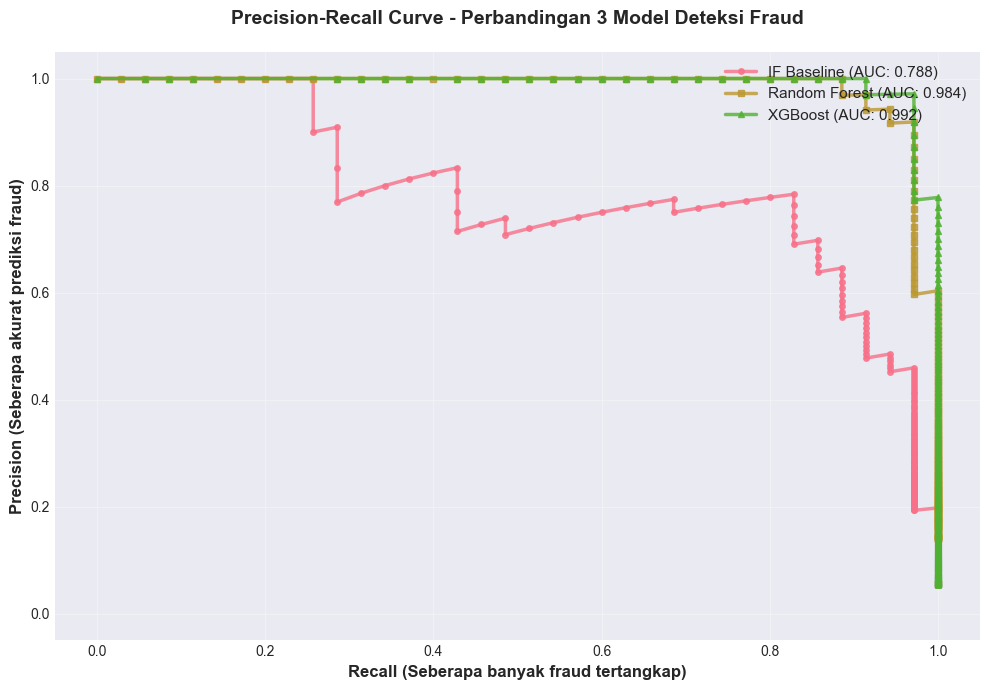

   Plot selesai

  Interpretasi:
    - Kurva yang lebih ke atas & kanan = performa lebih baik
    - PR-AUC lebih tinggi = keseimbangan precision-recall lebih baik
    - Cocok untuk data tidak seimbang (fraud minoritas)


In [14]:
print("[5/7] Visualisasi Precision-Recall Curve...\n")

# Hitung precision-recall curve
precision_if, recall_if, _ = precision_recall_curve(y_te, y_proba_if)
precision_rf, recall_rf, _ = precision_recall_curve(y_te, y_proba_rf)

if y_proba_xgb is not None:
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_te, y_proba_xgb)

# Buat plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot PR curve
ax.plot(recall_if, precision_if, label=f"IF Baseline (AUC: {pr_auc_if:.3f})", 
        marker='o', linewidth=2.5, markersize=4, alpha=0.8)
ax.plot(recall_rf, precision_rf, label=f"Random Forest (AUC: {pr_auc_rf:.3f})", 
        marker='s', linewidth=2.5, markersize=4, alpha=0.8)

if y_proba_xgb is not None:
    ax.plot(recall_xgb, precision_xgb, label=f"XGBoost (AUC: {pr_auc_xgb:.3f})", 
            marker='^', linewidth=2.5, markersize=4, alpha=0.8)

ax.set_xlabel("Recall (Seberapa banyak fraud tertangkap)", fontsize=12, fontweight='bold')
ax.set_ylabel("Precision (Seberapa akurat prediksi fraud)", fontsize=12, fontweight='bold')
ax.set_title("Precision-Recall Curve - Perbandingan 3 Model Deteksi Fraud", 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("   Plot selesai")
print("\n  Interpretasi:")
print("    - Kurva yang lebih ke atas & kanan = performa lebih baik")
print("    - PR-AUC lebih tinggi = keseimbangan precision-recall lebih baik")
print("    - Cocok untuk data tidak seimbang (fraud minoritas)")

##  Kesimpulan & Catatan Jujur

In [15]:
print("[6/7] Kesimpulan & Catatan Jujur...\n")

print(" KESIMPULAN & CATATAN JUJUR")

print("\n1. RINGKASAN PERFORMA:")
print(f"   - IF Baseline  : F1={f1_if:.3f}, PR-AUC={pr_auc_if:.3f}")
print(f"   - Random Forest: F1={f1_rf:.3f}, PR-AUC={pr_auc_rf:.3f}")
if y_pred_xgb is not None:
    print(f"   - XGBoost      : F1={f1_xgb:.3f}, PR-AUC={pr_auc_xgb:.3f}")

print("\n2. CATATAN JUJUR TENTANG EVALUASI INI:")
print("   [A] Data SINTETIS (buatan), bukan data nyata dari toko sesungguhnya.")
print("   [B] Kondisi TERKONTROL: fraud diinjeksi dengan pola tertentu yang mudah.")
print("   [C] Label SEMPURNA: is_fraud sudah diketahui (di dunia nyata, tidak pasti).")
print("   [D] Sebaran SEIMBANG: fraud = ~11% (di toko nyata bisa berbeda).")
print("   [E] Fitur BERSIH: tidak ada data leakage atau noise kompleks.")

print("\n3. IMPLIKASI PRAKTIS:")
print("    Angka di atas BUKAN jaminan kinerja di dunia nyata.")
print("    Model perlu di-retest dengan data historis toko nyata.")
print("    Fraud nyata mungkin lebih halus atau tidak sesuai pola sintetis.")
print("    Model perlu monitoring & retraining berkala.")


print("\nEvaluasi selesai!")


[6/7] Kesimpulan & Catatan Jujur...

 KESIMPULAN & CATATAN JUJUR

1. RINGKASAN PERFORMA:
   - IF Baseline  : F1=0.771, PR-AUC=0.788
   - Random Forest: F1=0.943, PR-AUC=0.984
   - XGBoost      : F1=0.971, PR-AUC=0.992

2. CATATAN JUJUR TENTANG EVALUASI INI:
   [A] Data SINTETIS (buatan), bukan data nyata dari toko sesungguhnya.
   [B] Kondisi TERKONTROL: fraud diinjeksi dengan pola tertentu yang mudah.
   [C] Label SEMPURNA: is_fraud sudah diketahui (di dunia nyata, tidak pasti).
   [D] Sebaran SEIMBANG: fraud = ~11% (di toko nyata bisa berbeda).
   [E] Fitur BERSIH: tidak ada data leakage atau noise kompleks.

3. IMPLIKASI PRAKTIS:
    Angka di atas BUKAN jaminan kinerja di dunia nyata.
    Model perlu di-retest dengan data historis toko nyata.
    Fraud nyata mungkin lebih halus atau tidak sesuai pola sintetis.
    Model perlu monitoring & retraining berkala.

Evaluasi selesai!
